In [35]:
from sklearn.datasets import load_iris
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [60]:
dataset = load_iris()
print("iris data loaded")

# print(f"dataset.data {dataset.data}")
# print(f"dataset.target{dataset.target}")
# print(f"target names: {dataset.target_names}")
Y = dataset.target
X = dataset.data

iris data loaded


In [61]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8)
print(X_train.shape)
print(Y_train.shape)

(120, 4)
(120,)


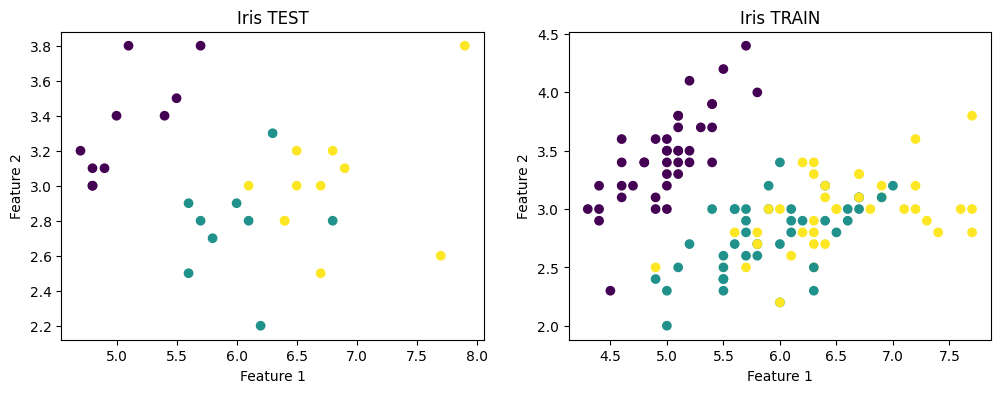

In [62]:
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_test)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Iris TEST")
plt.subplot(122)
plt.scatter(X_train[:, 0], X_train[:, 1], c=Y_train, cmap="viridis")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Iris TRAIN")
plt.show()

score de base = 0.9666666666666667


score de base = 0.9666666666666667


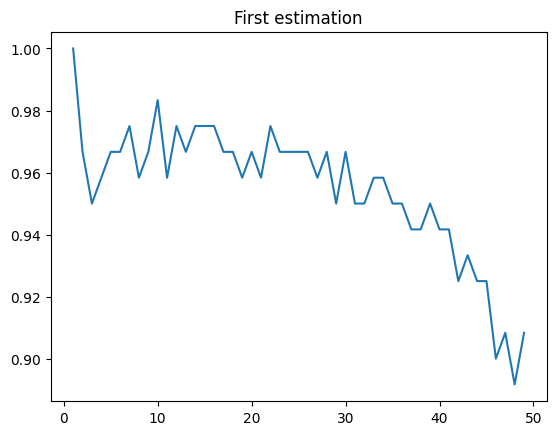

In [63]:
model = KNeighborsClassifier()
model.fit(X_train, Y_train)
scoredebase = model.score(X_train, Y_train)
print(f"score de base = {scoredebase}")
scores = []
for i in range(1, 50):
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train, Y_train)
    scoredebase = model.score(X_train, Y_train)
    scores.append(scoredebase)
scores
time = [i for i in range(1, 50)]
plt.plot(time, scores)
plt.title("First estimation")
plt.show()

from sklearn

In [40]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import validation_curve

In [65]:
crossvalscore = cross_val_score(KNeighborsClassifier(), X_train, Y_train, cv=5, scoring='accuracy')
crossvalscore.mean()


0.9416666666666667

In [66]:
KNeighborsClassifier().get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [67]:
train_score, val_curve = validation_curve(KNeighborsClassifier(), X_train, Y_train,param_range=time, param_name='n_neighbors', cv=5)
val_curve

array([[0.95833333, 0.95833333, 0.875     , 1.        , 0.95833333],
       [0.95833333, 0.95833333, 0.875     , 1.        , 0.95833333],
       [0.95833333, 1.        , 0.875     , 1.        , 0.95833333],
       [0.95833333, 0.95833333, 0.875     , 1.        , 0.95833333],
       [0.95833333, 0.95833333, 0.83333333, 1.        , 0.95833333],
       [0.95833333, 0.91666667, 0.875     , 1.        , 0.95833333],
       [0.95833333, 0.95833333, 0.83333333, 1.        , 0.95833333],
       [0.95833333, 0.91666667, 0.83333333, 1.        , 0.95833333],
       [0.95833333, 0.91666667, 0.83333333, 1.        , 0.95833333],
       [0.95833333, 0.91666667, 0.83333333, 1.        , 0.95833333],
       [1.        , 0.95833333, 0.83333333, 1.        , 0.95833333],
       [1.        , 0.91666667, 0.83333333, 1.        , 0.95833333],
       [1.        , 0.91666667, 0.83333333, 1.        , 0.95833333],
       [1.        , 0.91666667, 0.83333333, 1.        , 0.95833333],
       [1.        , 0.91666667, 0.

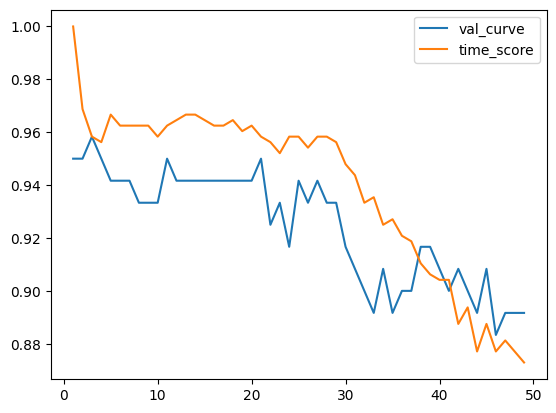

In [68]:
plt.plot(time, val_curve.mean(axis=1), label="val_curve")
plt.plot(time, train_score.mean(axis=1), label="time_score")
plt.legend()
plt.show()

on voit direct que le max est atteint a entre [10 : 20]

In [45]:
from sklearn.model_selection import GridSearchCV

In [70]:
KNeighborsClassifier().get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [47]:
param_grid = {
    'n_neighbors': np.arange(1, 20),
    'metric': ['minkowski', 'eucludian', 'manhattan'],
    'weights':['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

In [72]:
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, Y_train)

/home/fabio-chaput/Documents/portfolio/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
760 fits failed out of a total of 2280.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
760 fits failed with the following error:
Traceback (most recent call last):
  File "/home/fabio-chaput/Documents/portfolio/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/fabio-chaput/Documents/portfolio/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/home/fabio-chaput/Documents/portfolio/.venv/lib/python3.12/site-packages/sklearn

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'metric': ['minkowski', 'eucludian', 'manhattan'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                         'weights': ['uniform', 'distance']})

In [73]:
grid.best_params_

{'algorithm': 'auto',
 'metric': 'manhattan',
 'n_neighbors': 14,
 'weights': 'uniform'}

In [50]:
model = grid.best_estimator_

In [51]:
model.score(X_test, Y_test)

1.0